# District & Crop Clustering

Use unsupervised learning (K-Means + PCA) to discover natural groupings.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
df = pd.read_csv("./data/final_merged_data_rain_plus_crop_yield.csv")
print(f"Loaded: {df.shape}")

Loaded: (19439, 23)


## 1. Aggregate Data to District Level

Each district becomes one row with aggregated features.

In [4]:
district_agg = df.groupby('District').agg(
    avg_yield=('Yield', 'mean'),
    std_yield=('Yield', 'std'),
    avg_area=('Area', 'mean'),
    avg_production=('Production', 'mean'),
    num_crops=('Crop', 'nunique'),
    num_records=('Yield', 'count'),
    avg_june_rain=('june_actual_rainfall', 'mean'),
    avg_july_rain=('july_actual_rainfall', 'mean'),
    avg_aug_rain=('august_actual_rainfall', 'mean'),
    avg_sept_rain=('september_actual_rainfall', 'mean'),
).reset_index()

print(f"District features: {district_agg.shape}")
district_agg.head()

District features: (34, 11)


,District,avg_yield,std_yield,avg_area,avg_production,num_crops,num_records,avg_june_rain,avg_july_rain,avg_aug_rain,avg_sept_rain
0,ahilyanagar,0.918276,3.243231,38596.268497,38833.598484,27,752,124.038697,106.953324,113.417420,168.023537
1,akola,1.107736,3.733991,29879.839940,36130.664870,25,499,138.467936,237.442886,193.418437,133.560120
2,amravati,0.986473,3.563920,37293.403310,42457.855575,26,574,150.791638,256.090418,213.486760,156.108885
3,beed,0.825877,4.980285,35625.094396,33077.018202,27,712,127.648876,143.792556,145.044242,184.332865
4,bhandara,1.038254,4.146539,14863.902833,20212.398310,24,420,189.527619,361.172143,351.473810,196.740714


## 2. Standardize Features

In [5]:
feature_cols = [c for c in district_agg.columns if c != 'District']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(district_agg[feature_cols])
print(f"Scaled shape: {X_scaled.shape}")

Scaled shape: (34, 10)


## 3. Elbow Method — Optimal Number of Clusters

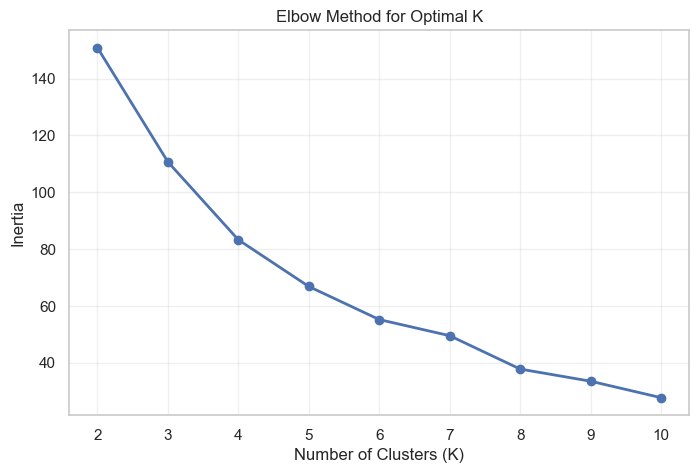

In [6]:
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True, alpha=0.3)
plt.show()

## 4. K-Means Clustering

In [7]:
K = 4  # Choose based on elbow plot above
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
district_agg['Cluster'] = kmeans.fit_predict(X_scaled)

print("Districts per cluster:")
for c in range(K):
    districts = district_agg[district_agg['Cluster'] == c]['District'].tolist()
    print(f"  Cluster {c}: {districts}")

Districts per cluster:
  Cluster 0: ['jalgaon', 'kolhapur', 'nandurbar']
  Cluster 1: ['palghar', 'raigad', 'ratnagiri', 'sindhudurg', 'thane']
  Cluster 2: ['bhandara', 'chandrapur', 'gadchiroli', 'gondia', 'hingoli', 'washim']
  Cluster 3: ['ahilyanagar', 'akola', 'amravati', 'beed', 'buldhana', 'chhatrapati sambhajinagar', 'dharashiv', 'dhule', 'jalna', 'latur', 'nagpur', 'nanded', 'nashik', 'parbhani', 'pune', 'sangli', 'satara', 'solapur', 'wardha', 'yavatmal']


## 5. PCA Visualization — 2D

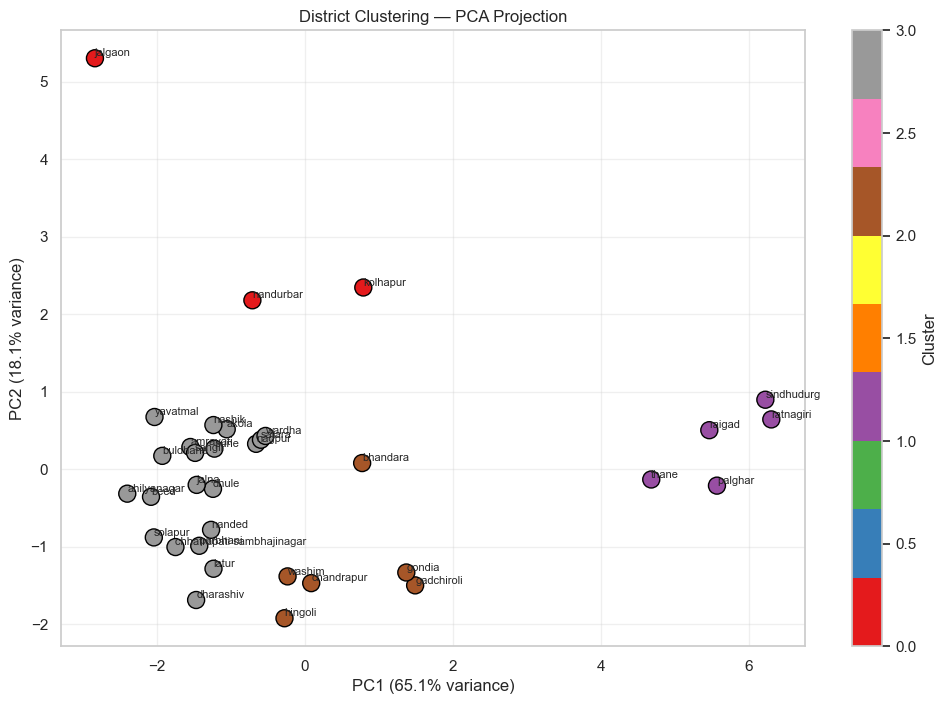

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=district_agg['Cluster'], cmap='Set1', s=150, edgecolors='black')

for i, name in enumerate(district_agg['District']):
    plt.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=8, ha='left', va='bottom')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('District Clustering — PCA Projection')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Cluster Profiling

In [9]:
profile = district_agg.groupby('Cluster')[feature_cols].mean().round(2)
print("Cluster Profiles (mean values):\n")
print(profile.T.to_string())

Cluster Profiles (mean values):

Cluster                0         1         2         3
avg_yield           1.53      1.06      0.84      0.95
std_yield           8.76      0.86      1.21      3.35
avg_area        21530.63   7988.38  17772.90  30144.19
avg_production  40714.85  16623.75  21183.37  34565.92
num_crops          25.00     18.80     24.50     26.35
num_records       633.00    320.80    490.67    649.60
avg_june_rain     196.58    674.42    183.50    146.57
avg_july_rain     356.04   1094.00    352.73    217.61
avg_aug_rain      288.82    724.26    310.39    187.00
avg_sept_rain     184.72    446.77    193.54    167.67


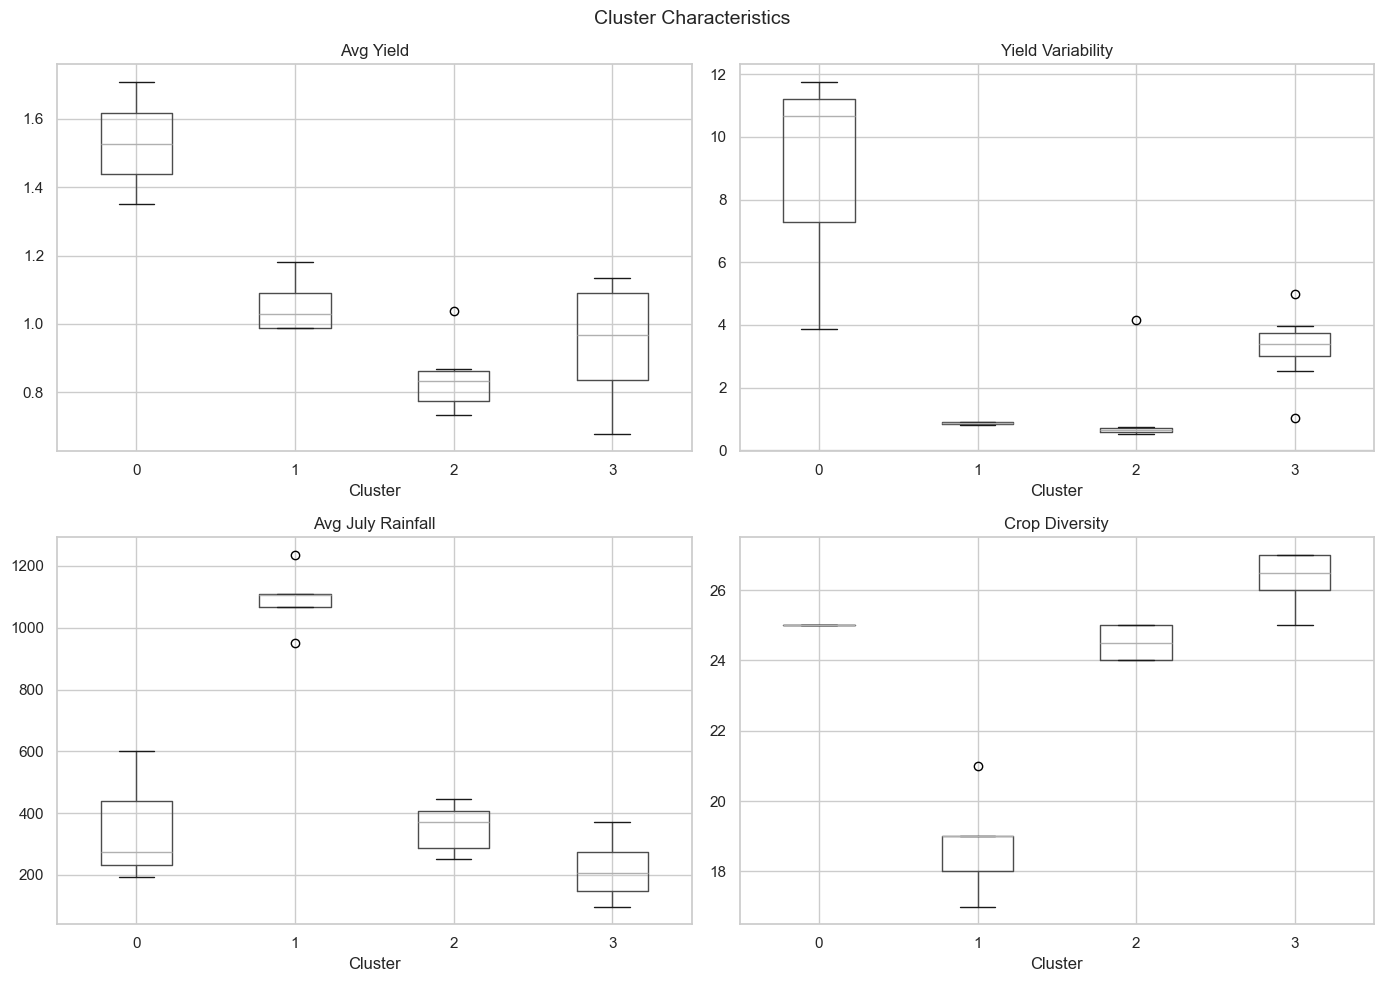

In [10]:
# Visualize key differences between clusters
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, title in [
    (axes[0][0], 'avg_yield', 'Avg Yield'),
    (axes[0][1], 'std_yield', 'Yield Variability'),
    (axes[1][0], 'avg_july_rain', 'Avg July Rainfall'),
    (axes[1][1], 'num_crops', 'Crop Diversity'),
]:
    district_agg.boxplot(column=col, by='Cluster', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Cluster')

plt.suptitle('Cluster Characteristics', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Crop Clustering

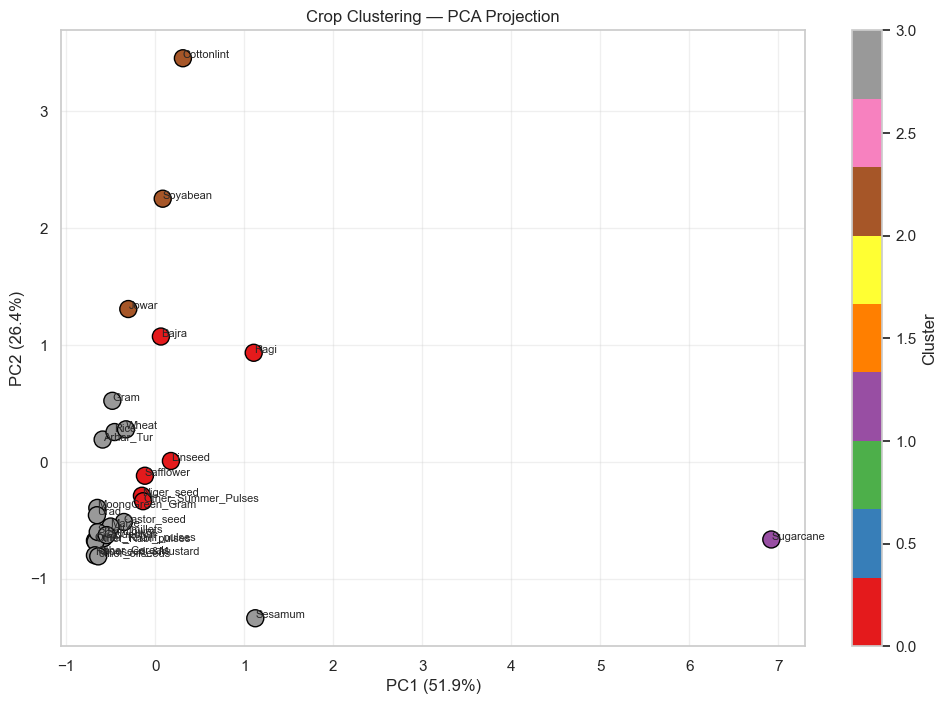


Crops per cluster:
  Cluster 0: ['Bajra', 'Linseed', 'Niger_seed', 'Other_Summer_Pulses', 'Ragi', 'Safflower']
  Cluster 1: ['Sugarcane']
  Cluster 2: ['Cottonlint', 'Jowar', 'Soyabean']
  Cluster 3: ['Arhar_Tur', 'Castor_seed', 'Gram', 'Groundnut', 'Maize', 'MoongGreen_Gram', 'Other_Cereals', 'Other_Kharif_pulses', 'Other_Rabi_pulses', 'Rapeseed_&Mustard', 'Rice', 'Sesamum', 'Small_millets', 'Sunflower', 'Urad', 'Wheat', 'other_oilseeds']


In [11]:
crop_agg = df.groupby('Crop').agg(
    avg_yield=('Yield', 'mean'),
    std_yield=('Yield', 'std'),
    avg_area=('Area', 'mean'),
    num_districts=('District', 'nunique'),
).reset_index()

crop_features = [c for c in crop_agg.columns if c != 'Crop']
X_crop = StandardScaler().fit_transform(crop_agg[crop_features])

km_crop = KMeans(n_clusters=4, random_state=42, n_init=10)
crop_agg['Cluster'] = km_crop.fit_predict(X_crop)

pca_crop = PCA(n_components=2)
X_crop_pca = pca_crop.fit_transform(X_crop)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_crop_pca[:, 0], X_crop_pca[:, 1], c=crop_agg['Cluster'], cmap='Set1', s=150, edgecolors='black')

for i, name in enumerate(crop_agg['Crop']):
    plt.annotate(name, (X_crop_pca[i, 0], X_crop_pca[i, 1]), fontsize=8, ha='left')

plt.xlabel(f'PC1 ({pca_crop.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_crop.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Crop Clustering — PCA Projection')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

print("\nCrops per cluster:")
for c in range(4):
    crops = crop_agg[crop_agg['Cluster'] == c]['Crop'].tolist()
    print(f"  Cluster {c}: {crops}")